# Quantum memory with circuit-level noise

A circuit-level memory experiment prepares a logical state, repeatedly measures its stabilizers, and finally checks whether a logical observable flipped.
Unlike the code-capacity model, faulty gates, resets, measurements, and idle moments can all create detector events.

This notebook runs the simple fixed-basis experiment one basis at a time.
An X-basis experiment tracks X-type logical observables and a Z-basis experiment tracks Z-type logical observables.
Choosing roughly $d$ syndrome rounds is a common benchmark convention, not the definition of a QEC cycle.


## Setup

Install the dependencies once in the environment that will run the notebook:

```bash
python -m pip install qldpc matplotlib
```


In [1]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter

from qldpc import circuits, codes, decoders
from qldpc.objects import Pauli, PauliXZ

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

## Build Sinter tasks

Each `(code, rounds)` pair states the circuit depth explicitly.
For the examples below the supplied round count equals a known exact distance, but the simulation helper does not pretend that a randomized distance upper bound is exact.


In [2]:
def code_label(code):
    known_distance = code.get_distance_if_known()
    suffix = f", {known_distance}" if known_distance is not None else ""
    return f"[[{len(code)}, {code.dimension}{suffix}]]"


def run_memory_experiments(
    codes_and_rounds: Sequence[tuple[codes.CSSCode, int]],
    basis: PauliXZ,
    decoder: sinter.Decoder,
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-3, -2, 5)),
    max_shots: int = 20_000,
    max_errors: int = 100,
):
    tasks = []
    for code, num_rounds in codes_and_rounds:
        assert num_rounds >= 1
        for probability in error_rates:
            noise = circuits.DepolarizingNoiseModel(
                probability,
                include_idling_error=False,
            )
            circuit = circuits.get_memory_experiment(
                code,
                basis=basis,
                num_rounds=num_rounds,
                noise_model=noise,
            )
            tasks.append(
                sinter.Task(
                    circuit=circuit,
                    json_metadata={
                        "label": code_label(code),
                        "probability": probability,
                    },
                )
            )

    return sinter.collect(
        tasks=tasks,
        decoders=["qldpc"],
        custom_decoders={"qldpc": decoder},
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


def plot_fixed_basis_results(codes_and_rounds, decoder):
    figure, axes = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
    markers = ("o", "s", "^", "D")

    for axis, basis in zip(axes, (Pauli.X, Pauli.Z)):
        stats = run_memory_experiments(codes_and_rounds, basis, decoder)
        sinter.plot_error_rate(
            ax=axis,
            stats=stats,
            x_func=lambda stat: stat.json_metadata["probability"],
            group_func=lambda stat: stat.json_metadata["label"],
            plot_args_func=lambda index, _curve_id: {
                "marker": markers[index % len(markers)],
            },
        )
        reference_rates = sorted({stat.json_metadata["probability"] for stat in stats})
        axis.plot(
            reference_rates,
            reference_rates,
            color="black",
            linestyle=":",
            label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
        )
        axis.set_title(f"{basis.name}-basis memory")
        axis.set_xlabel("physical error rate per operation")
        axis.loglog()
        axis.grid(which="both", alpha=0.3)

    axes[0].set_ylabel("estimated logical error rate")
    axes[1].legend(loc="best")
    figure.tight_layout()
    return figure, axes

## Surface codes with MWPM

The fixed-basis circuit uses one code block and only records the chosen family of logical observables.
MWPM decodes the graphlike detector error model for these surface-code circuits.


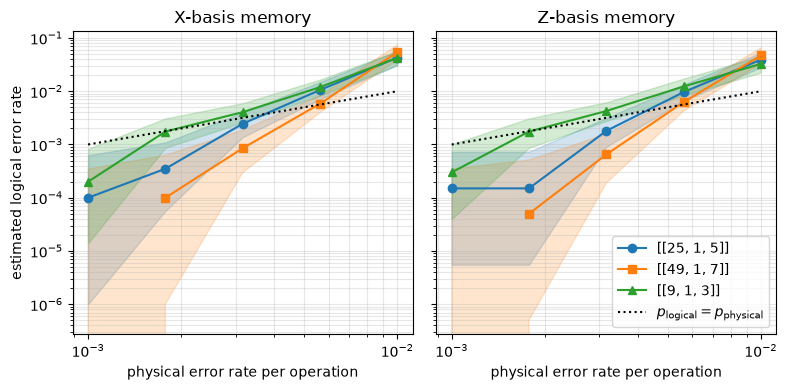

In [3]:
surface_codes = [(codes.SurfaceCode(distance, rotated=True), distance) for distance in (3, 5, 7)]
mwpm_decoder = decoders.SinterDecoder(with_MWPM=True)

plot_fixed_basis_results(surface_codes, mwpm_decoder)
plt.show()

Within this bounded run, the two panels need not match exactly: circuit geometry and finite sampling can make X- and Z-basis estimates differ.
Sinter's shaded regions contain rates whose likelihood is within a factor of 1,000 of the best fit; they are not one-standard-deviation or 95% intervals.


## Toric codes with BP+LSD

Changing the decoder does not require rebuilding the plotting machinery.
BP+LSD handles the non-graphlike decoding problem directly, at greater computational cost.


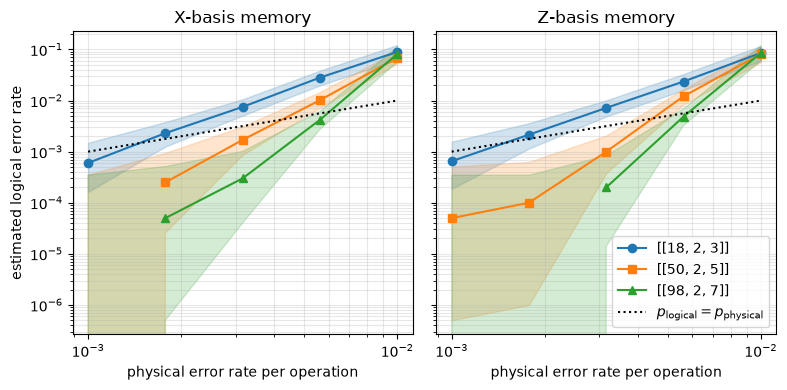

In [4]:
toric_codes = [(codes.ToricCode(distance, rotated=False), distance) for distance in (3, 5, 7)]
bp_lsd_decoder = decoders.SinterDecoder(
    with_BP_LSD=True,
    max_iter=30,
    bp_method="ms",
    lsd_method="lsd_cs",
    lsd_order=0,
)

plot_fixed_basis_results(toric_codes, bp_lsd_decoder)
plt.show()

The curves are estimates for the stated circuits, decoder, and stopping rules.
More shots reduce sampling uncertainty but do not remove decoder bias or prove asymptotic scaling.
